In [1]:
pip install boruta

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install feature_engine


   ---------------------------------------- 0.0/375.0 kB ? eta -:--:--
   ---- ---------------------------------- 41.0/375.0 kB 991.0 kB/s eta 0:00:01
   --------- ------------------------------ 92.2/375.0 kB 1.3 MB/s eta 0:00:01
   ----------------- ---------------------- 163.8/375.0 kB 1.6 MB/s eta 0:00:01
   ------------------------ --------------- 225.3/375.0 kB 1.5 MB/s eta 0:00:01
   ----------------------------- ---------- 276.5/375.0 kB 1.4 MB/s eta 0:00:01
   ------------------------------------ --- 337.9/375.0 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 375.0/375.0 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.6 MB 1.7 MB/s eta 0:00:07
   ---------------------------------------- 0.1/11.6 MB 1.6 MB/s eta 0:00:08
    --------------------------------------- 0.2/11.6 MB 1.6 MB/s eta 0:00:07
   - -------------------------------------- 0.3/11.6 MB 1.8 MB/s eta

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pycaret 3.3.2 requires pandas<2.2.0, but you have pandas 2.2.3 which is incompatible.
sktime 0.26.0 requires pandas<2.2.0,>=1.1, but you have pandas 2.2.3 which is incompatible.


In [5]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
import shap
from feature_engine.selection import DropCorrelatedFeatures

In [8]:
# 타이타닉 데이터로 보루타 알고리듬으로 피처를 선정하자!
df = sns.load_dataset('titanic')

# 데이터 전처리
df = df.dropna(subset=['age', 'embarked', 'deck'])
df['sex'] = df['sex'].map({'male' : 0, 'female' : 1})
df['embarked'] = df['embarked'].astype('category').cat.codes
df['deck'] = df['deck'].astype('category').cat.codes

# 필요한 피처만 추출
X = df[['pclass', 'sex','age','sibsp','parch','fare','embarked','deck']]
y = df['survived']

In [16]:
## 보루타를 통한 피처셀렉션을 위해 RandomForestClassifier

rf = RandomForestClassifier(class_weight = 'balanced', max_depth = 5)

# BorutaPy 불러오기
boruta_selector = BorutaPy(rf, n_estimators = 'auto', random_state = 111)
boruta_selector.fit(X.values, y.values) # 행렬로 대입

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                          n_estimators=80,
                                          random_state=RandomState(MT19937) at 0x14E832DDD40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x14E832DDD40)

In [17]:
print('선택된 특성', X.columns[boruta_selector.support_].tolist())

선택된 특성 ['sex', 'age', 'fare']


- 모든 특성의 중요도를 평가하고, 쉐도우 변수를 만들어서 중요도가 무작위로 중요도를 뽑아서 비교하고 이 무작위보다 높은 중요도가 높은 특성들을 추출한 것

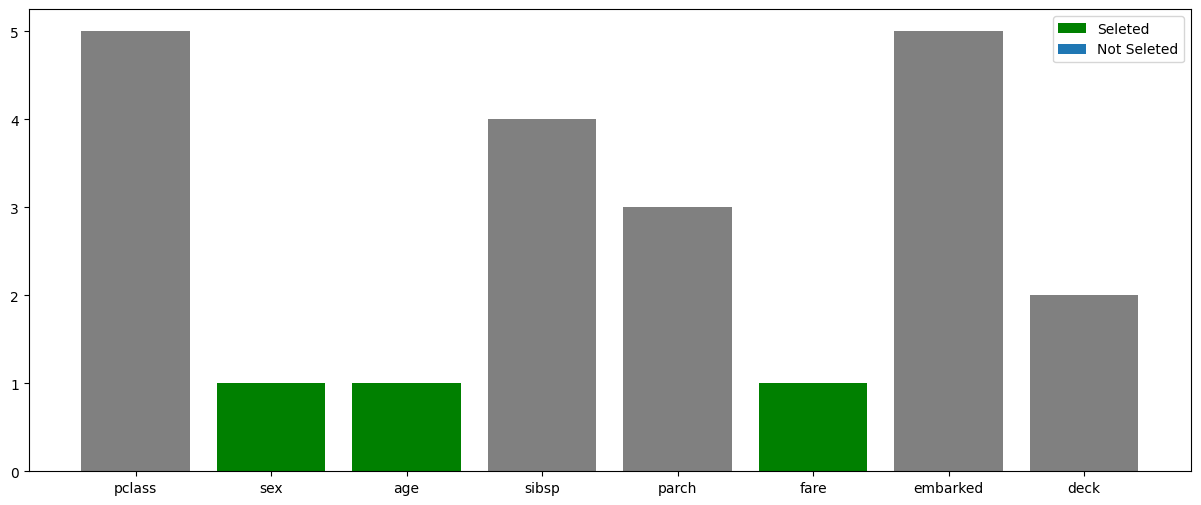

In [21]:
import matplotlib.pyplot as plt

green_area = X.columns[boruta_selector.support_].tolist()
blue_area = X.columns[boruta_selector.support_weak_].tolist()

# 중요도 랭킹으로 확인하기
feature_importance = boruta_selector.ranking_

# 시각화로 살펴보기
plt.figure(figsize=(15,6))
plt.bar(X.columns, feature_importance,color= 'grey')
plt.bar(green_area, [1]*len(green_area), color='green', label='Seleted')
plt.bar(blue_area, [2]*len(blue_area), color='blue', label='Not Seleted')
plt.legend()

### shap Value(샤플리 값)
- 샤플리 값의 작동방식을 이해하자!
- 간단한 예시를 통해 어떤 식으로 계산하는지 이해하기
    - 세명의 플레이어(피처) A,B,C 가 협력해서 100의 매출들 달성 (ML y값을 예측한다)
    - A와 B가 같이 혁력을 하면 매출 60을 달성
    - B와 C가 같이 협력을 하면 매출 50을 달성
    - A, B, C가 모두 협력을 하면 100을 달성
    - 기여도는 어떤 식으로 계산이 될까?
        - 각 조합의 기여도를 계산
        - 공집합 = 기여도가 0 => A,B,C 모두 진행하지 않음
        - A만 한 경우 20, B만 한 경우 30, C만 한 경우 10
        - A,B = 60, B,C = 50, A,C = 40
        - A,B,C = 100
    - 샤플리 값 A를 계산한다고 하면 샤플리 값 =1/6(20) + 1/6(10) +1/6(40-10) + 1/6(60-30) + 1/6(100-60)

- ML에서 샤플리 값을 예측한다면?
    - Feature 모델의 예측값에 기여한 정도를 계산하기 위해 샤플리 값을 사용한다.
    - 피처들의 조합으로 게임 플레이어처럼 생각하고, 모델의 예측값을 협력의 결과로 본다.
    - 데이터 포인트에 대해 모델의 예측값 계산
    - 모든 특성의 조합에서의ㅡ 예측값이 변화를 계산
    - 각 특성의 기여도를 평균화 하여 샤블리 값을 계싼

### 샤플리 값을 타이타닉 데이터로 설명을 해보면!
- 타이타닉의 주요 특성(피처) pclass, sex, age, fare 타겟변수는 survived
- 랜덤포레스트를 학습해서 특정 포인트에서 샤플리값을 계산해 본다.


----
- 특성 N은
    - Pclass(객실등급), Sex(성별), Age(나이), Fare(요금)
    
- **모든 특성의 조합을 생각해야 한다.**
    - 공집합,
    - Pclass
    - Sex
    - Age
    - Fare
    - (Pclass, Sex)
    - ...
    - (Pclass, Sex, Age, Fare)
    - 모든 조합을 생성한다.
    
- 모델의 예측값을 계산
    - 수식에서 바라보면
    - S = pclass i = sex , pclass와 sex를 함께 사용하여 예측값을 계산
    - f(SU{i} - f(S}) 특성인 sex 추가가 되었을 때 예측값에 미친 변화량을 계산

- 평균화
    - 모든 부분집합 (S)에 대한 기여도를 계산하는 것, 이를 평균화하여 특성 (i) 샤플리 값을 얻는 것

- 특정 데이터 포인트에 대해 샤플리값을 디 다계산이 된다.
- 변수     샤플리값     해석
- pclass  -0.3     낮은 객실등급들이 생존 확률을 감소시킨다.
- sex     +0.5     여성의 경우 생존확률 증가시킨다.
- age     -0.2     나이가 많아질수록 생존에 대한 확률이 감소
- fare    +0.1     운임이 높으면 생존확률을 증가시킨다.

    **- 타이타닉의 도메인을 이해하고 샤플리값을 바라보면 피처에 대한 선택과 인사이트를 상대적으로 쉽게 정리할 수 있다.**
    

In [24]:
from sklearn.model_selection import train_test_split

X = df[['sex', 'age', 'fare', 'pclass']]
y = df['survived']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 111)

In [26]:
model = RandomForestClassifier(random_state=111)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=111)

In [27]:
# shap 값 구하기
# shap Explainer

explainer=shap.TreeExplainer(model)

In [28]:
# shap_values 추출
shap_values=explainer.shap_values(X_test)

In [29]:
shap_values

array([[[ 2.26120951e-01, -2.26120951e-01],
        [ 2.20843057e-01, -2.20843057e-01],
        [-1.50570733e-01,  1.50570733e-01],
        [ 4.57224146e-03, -4.57224146e-03]],

       [[-1.32598920e-01,  1.32598920e-01],
        [-9.30407346e-02,  9.30407346e-02],
        [-4.92641395e-02,  4.92641395e-02],
        [-1.41306886e-02,  1.41306886e-02]],

       [[ 2.16852382e-01, -2.16852382e-01],
        [-1.60142407e-02,  1.60142407e-02],
        [ 6.20425437e-02, -6.20425437e-02],
        [ 8.08483220e-03, -8.08483220e-03]],

       [[-1.57080780e-01,  1.57080780e-01],
        [-5.72197003e-02,  5.72197003e-02],
        [-7.12934431e-02,  7.12934431e-02],
        [-3.44055969e-03,  3.44055969e-03]],

       [[ 1.89570819e-01, -1.89570819e-01],
        [-3.95938458e-02,  3.95938458e-02],
        [-8.08269752e-02,  8.08269752e-02],
        [ 1.81551923e-03, -1.81551923e-03]],

       [[-1.55140194e-01,  1.55140194e-01],
        [-5.97438146e-02,  5.97438146e-02],
        [-7.10227650e-

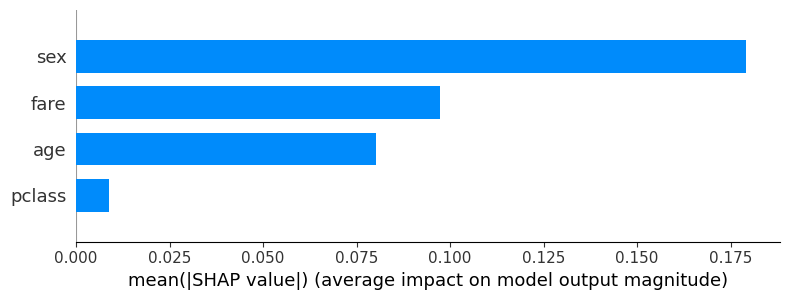

In [30]:
# 특정 클래스 선택 (예: 클래스 0)
shap_values_class_0 = shap_values[:,:,0]

# 요약 플롯 생성
shap.summary_plot(shap_values_class_0, X_test, plot_type='bar', feature_names = X_test.columns.tolist())

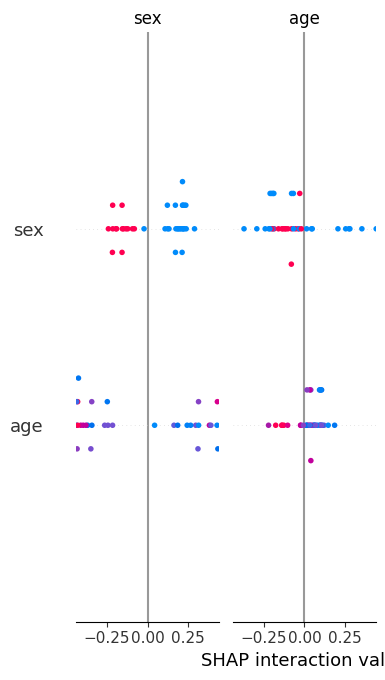

In [35]:
import numpy as np
feature_names = np.array(X_test.columns)  # Convert to a NumPy array
shap.summary_plot(shap_values, X_test, plot_type='bar', feature_names=feature_names)

In [38]:
print(f"shap_values shape: {shap_values[0].shape}")
print(f"X_test shape: {X_test.shape}")

shap_values shape: (4, 2)
X_test shape: (37, 4)
